### 1. Libraries

In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

In [ ]:
# Set option to display all columns
pd.set_option('display.max_columns', None)

### 2. Data Loading

In [ ]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

#### 3. Data Wrangling

#### 3.1 Structure Check

**Data Type and Dimension**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

Comment: There is no missing value. The test dataset does not contain the target variable, so the train dataset shall be split during the cross validation step. 

**Duplicate Rows**

In [ ]:
print("Duplicate rows:", df_train.duplicated().sum())
print("Duplicate rows:", df_test.duplicated().sum())

Duplicate rows: 0
Duplicate rows: 0


### 3.2. Column Check

#### 3.2.1. Column Type Classification

**Sample Inputs**

In [ ]:
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


**Unique Values**

In [ ]:
for col in df_train.columns:
    print(f"{col}: {df_train[col].nunique()} unique values")

id: 594194 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 72 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1921 unique values
TotalCharges: 31910 unique values
Churn: 2 unique values


**Numerical Variable Classification**

In [ ]:
# Numerical columns
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']  

**Categorical and Ordinal Variable Classification**

In [ ]:
# Columns excluding numerical columns
cols = [col for col in df_train.columns if col not in num_cols]

# Dropping primary key 'id'
cols.remove('id')

for col in cols:
    print(f"\nColumn: {col}")
    print(df_train[col].unique())


Column: gender
['Male' 'Female']

Column: SeniorCitizen
[0 1]

Column: Partner
['Yes' 'No']

Column: Dependents
['Yes' 'No']

Column: PhoneService
['Yes' 'No']

Column: MultipleLines
['No' 'Yes' 'No phone service']

Column: InternetService
['DSL' 'Fiber optic' 'No']

Column: OnlineSecurity
['Yes' 'No' 'No internet service']

Column: OnlineBackup
['No' 'Yes' 'No internet service']

Column: DeviceProtection
['Yes' 'No' 'No internet service']

Column: TechSupport
['Yes' 'No' 'No internet service']

Column: StreamingTV
['No' 'Yes' 'No internet service']

Column: StreamingMovies
['No' 'Yes' 'No internet service']

Column: Contract
['One year' 'Two year' 'Month-to-month']

Column: PaperlessBilling
['Yes' 'No']

Column: PaymentMethod
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']

Column: Churn
['No' 'Yes']


Comment:

Based on the input format of each of the column, the columns are classified as follows:

Numerical `num_cols`: ['MonthlyCharges', 'TotalCharges', 'tenure]

Ordinal: None

Categorical `cat_cols`: the rest

In [ ]:
cat_cols = cols[:]
del cols 
target_col = cat_cols.pop()


In [ ]:
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target column:", target_col)

Numerical columns: ['MonthlyCharges', 'TotalCharges', 'tenure']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target column: Churn


#### 3.2.2. Numerical Column Check

**Outlier Detection**

In [ ]:
# Train data
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Test data
df_test.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,254655.000000,254655.00000,254655.000000,254655.000000,254655.000000
mean,721521.000000,0.11362,37.279716,66.130803,2544.617351
std,73512.710738,0.31735,24.777625,31.104139,2348.124379
min,594194.000000,0.00000,1.000000,18.300000,18.800000
25%,657857.500000,0.00000,13.000000,30.150000,677.625000
50%,721521.000000,0.00000,36.000000,74.350000,1468.750000
75%,785184.500000,0.00000,62.000000,91.100000,4317.300000
max,848848.000000,1.00000,72.000000,118.750000,8684.800000


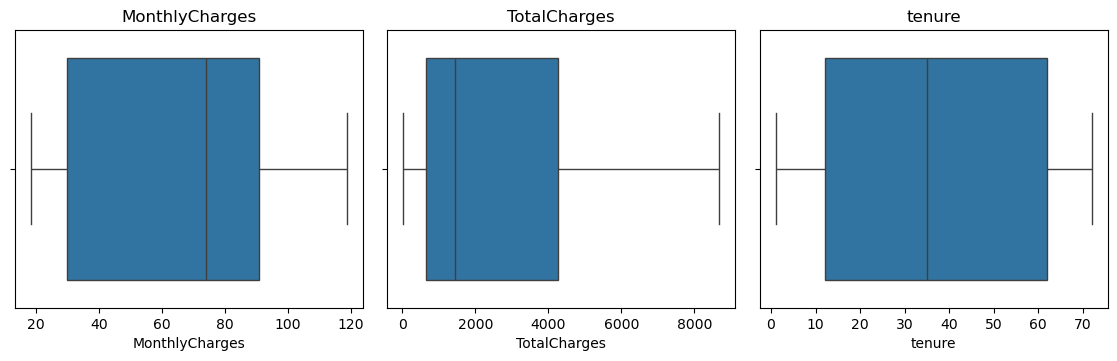

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):  # limit to avoid clutter
    plt.subplot(3, 4, i)
    sns.boxplot(x=df_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Comment: The values of the numerical columns do not show abnormality. 

**Variable distributions between Train and Test datasets**

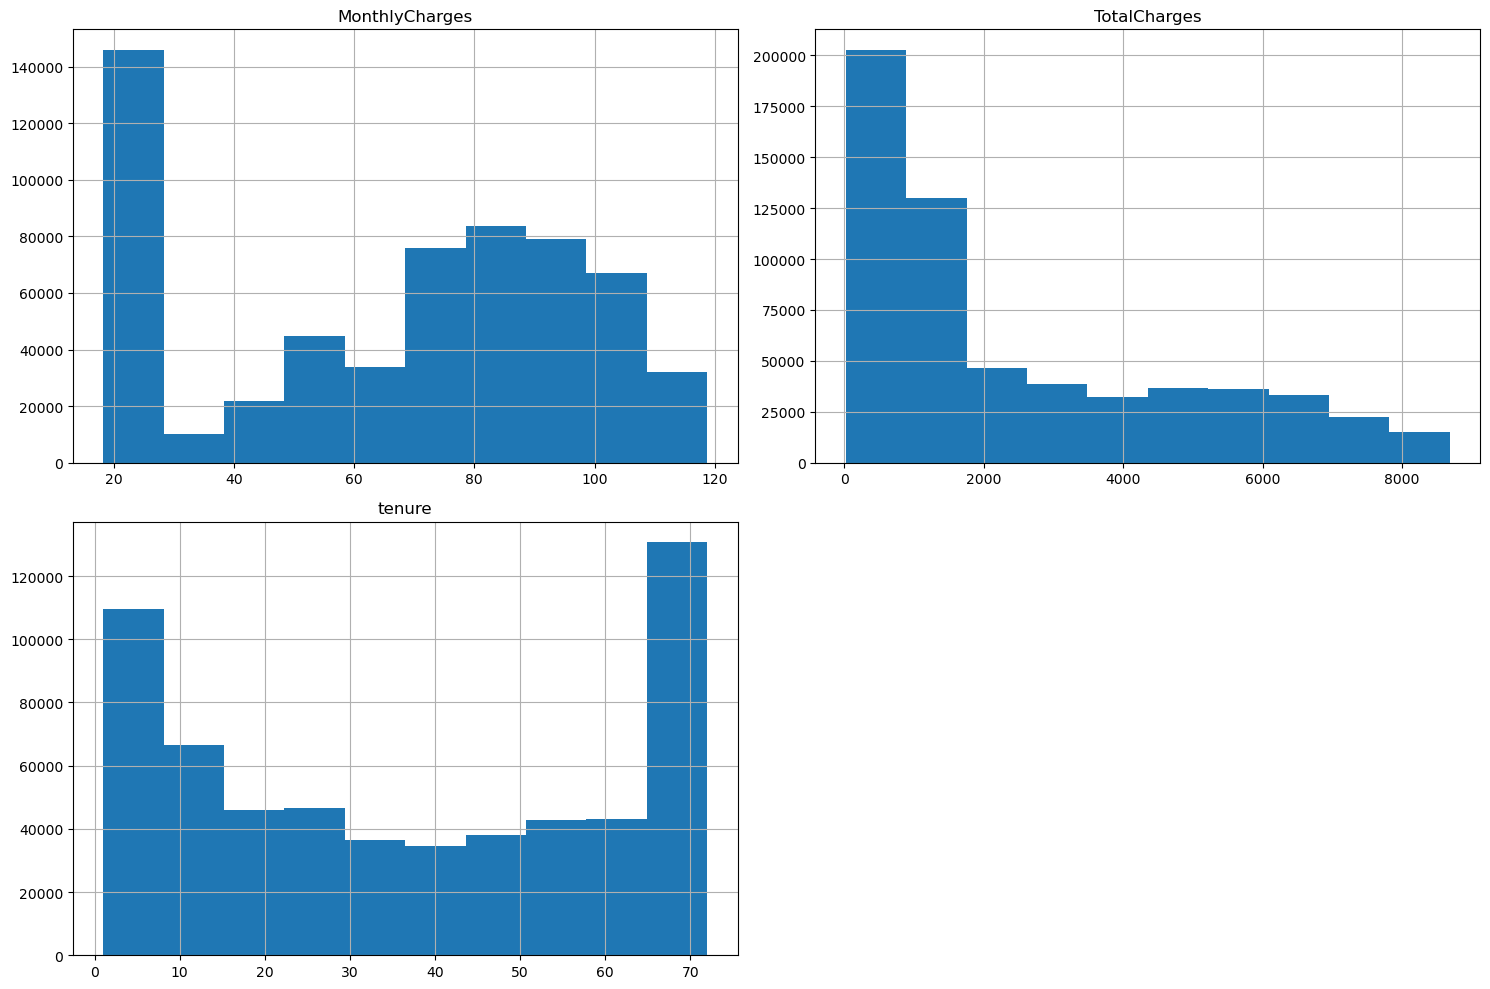

In [ ]:
df_train[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

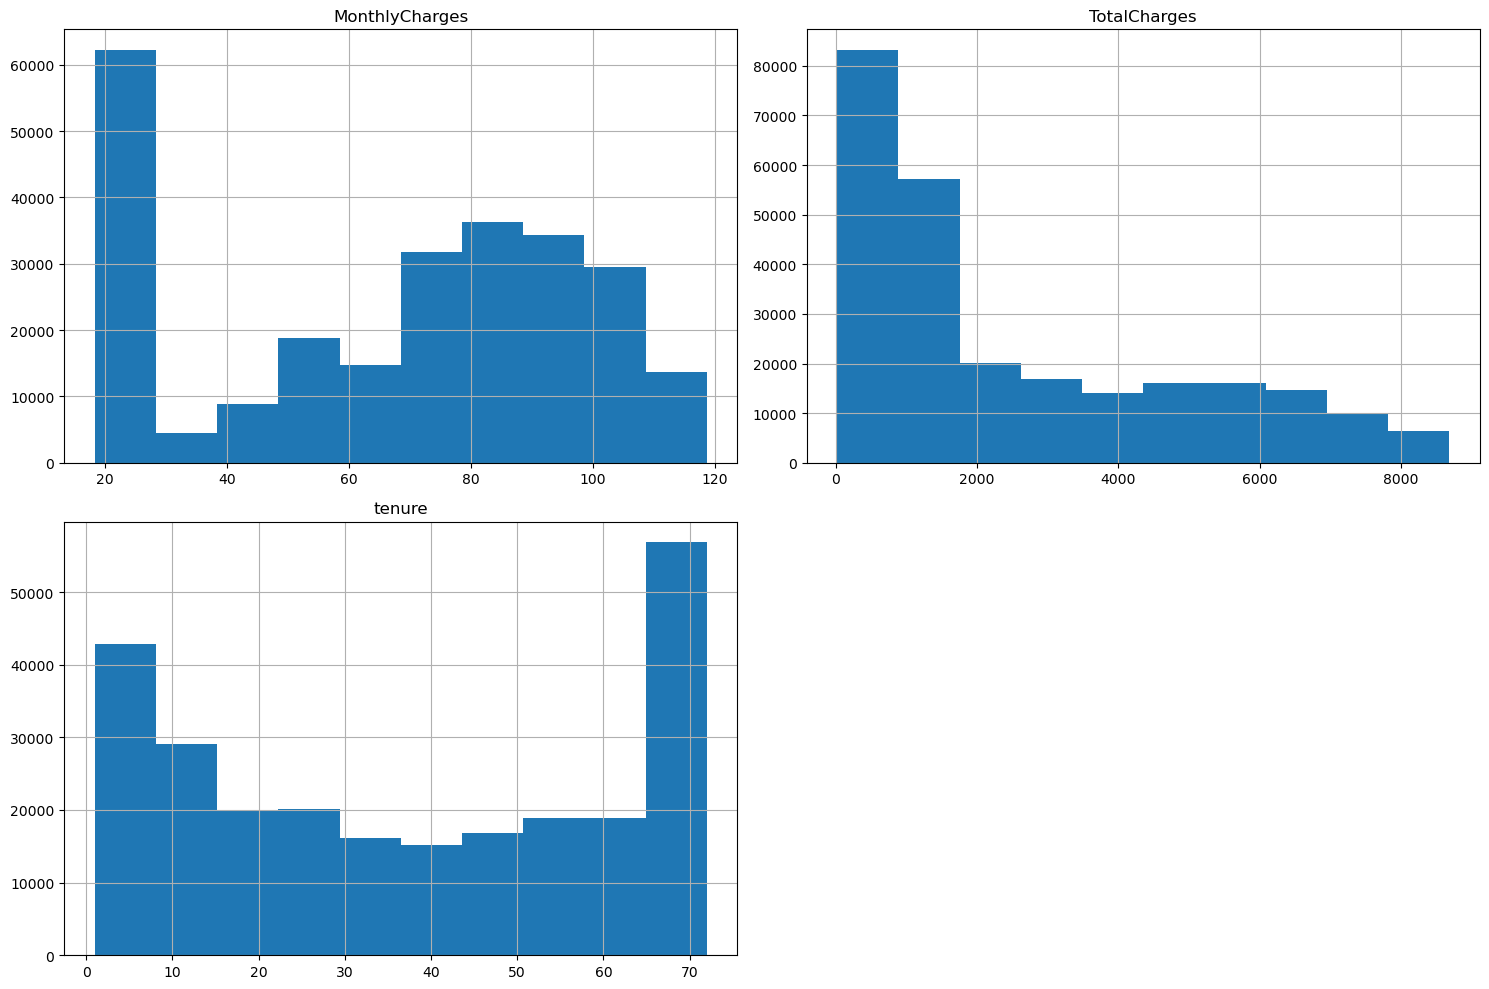

In [ ]:
df_test[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

**Comment:** The distributions of numerical variables in the train and test datasets show similar structure. 

#### 3.2.3. Categorical Column Check

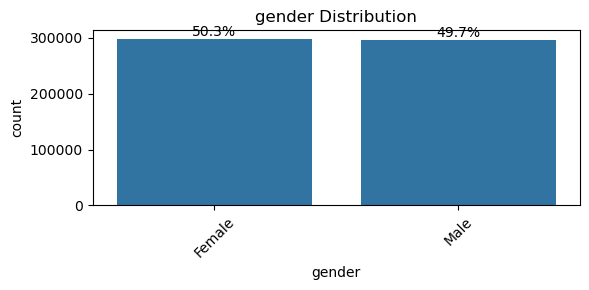

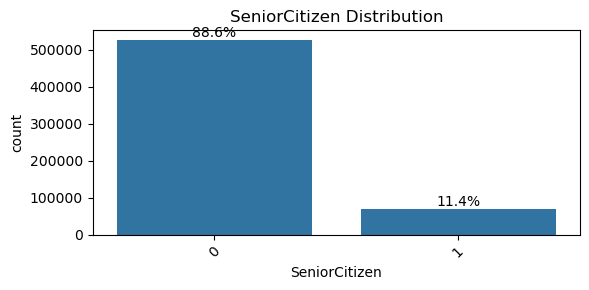

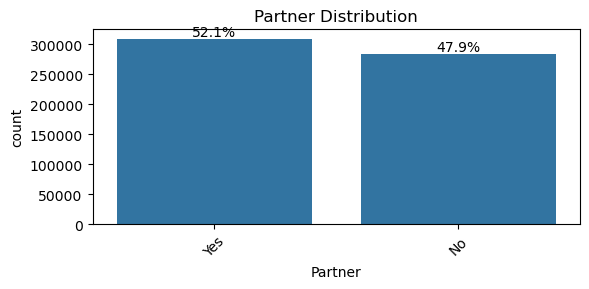

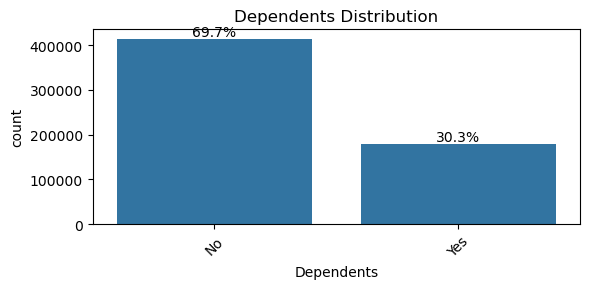

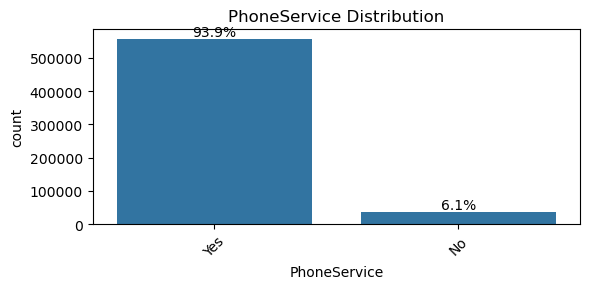

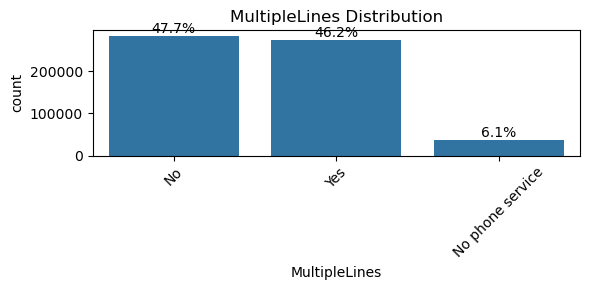

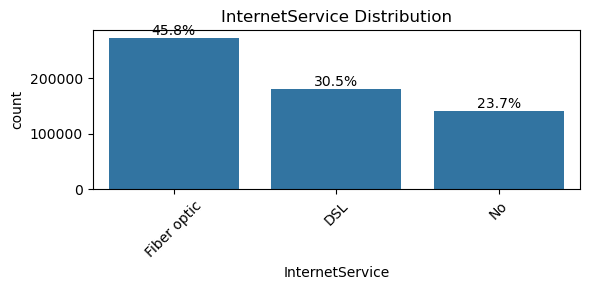

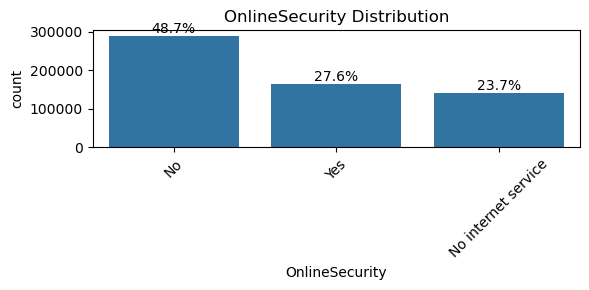

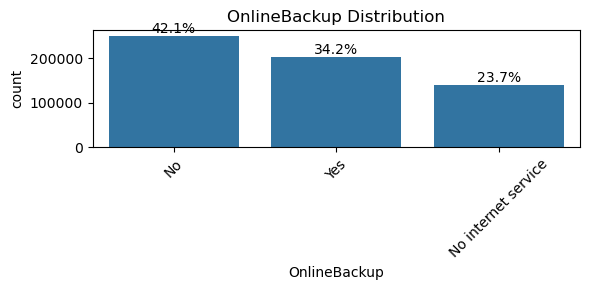

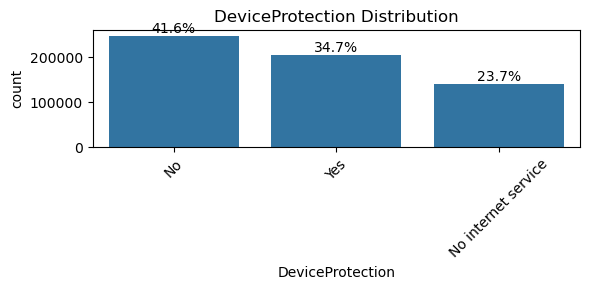

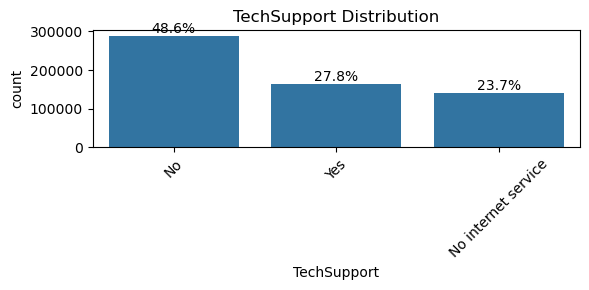

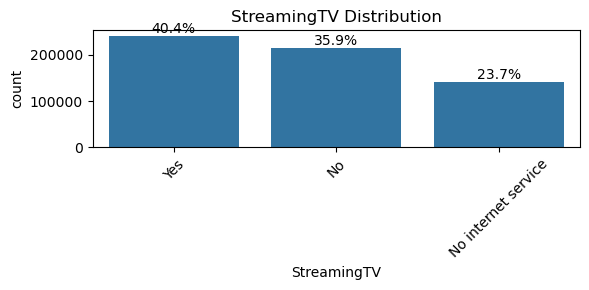

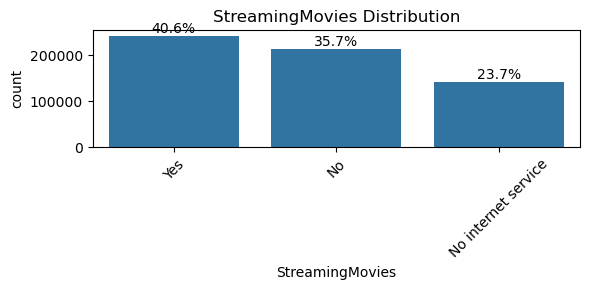

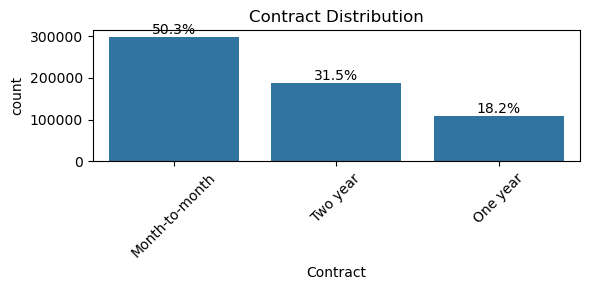

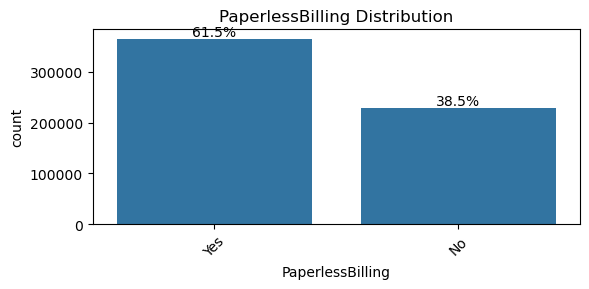

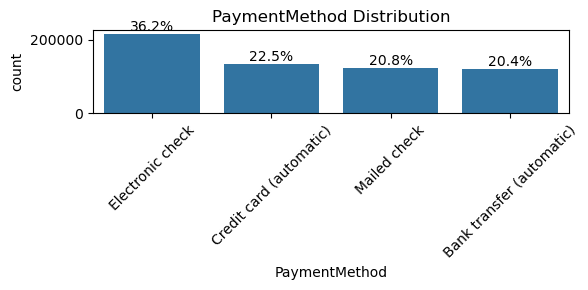

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    
    ax = sns.countplot(data=df_train, x=col, order=df_train[col].value_counts().index)
    
    total = len(df_train)
    
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')
    
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Comment: Columns with strong imbalance

Senior Citizen (0 – 88.6%, 1 – 11.4%)

Dependents (No – 69.7%, Yes, 30.3%)

PhoneService (Yes – 93.9%, No – 6.1%)

MultipleLines (No phone service – 6.1%) 


#### 3.2.4. Target Variable Distribution

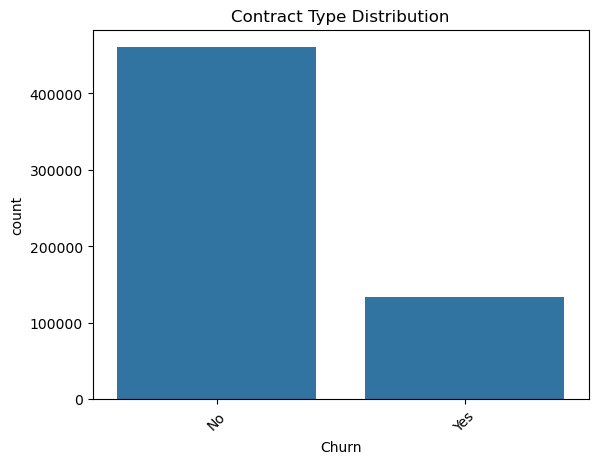

In [ ]:
sns.countplot(data=df_train, x='Churn')
plt.xticks(rotation=45)
plt.title("Contract Type Distribution")
plt.show()

Comment: There is a bit of imbalance between Yes and No datapoints.

### 3.3. Relationship Exploration

#### 3.3.1. Numerical Variables

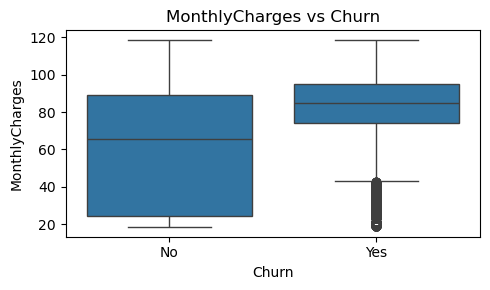

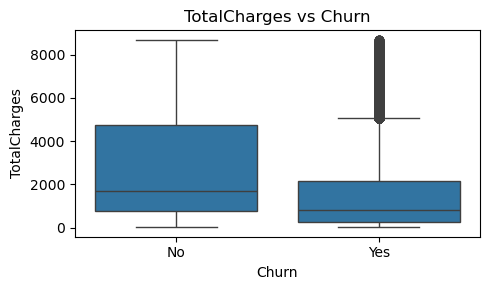

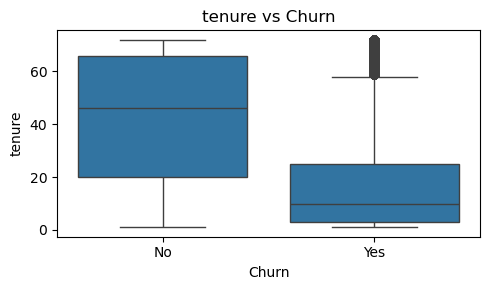

In [ ]:
# Box Plot, Numerical vs Target

for col in num_cols:
    plt.figure(figsize=(5, 3))
    
    sns.boxplot(data=df_train, x='Churn', y=col)
    
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

Comment:

MonthlyCharges: the higher the monthly charges, the higher the churn rate. 

TotalCharges: Customers who have been charged higher are more likely to stay. 

Tenure: Customers who have subscribed longer are more likely to persist being loyal. 

#### 3.3.2. Categorical Variables

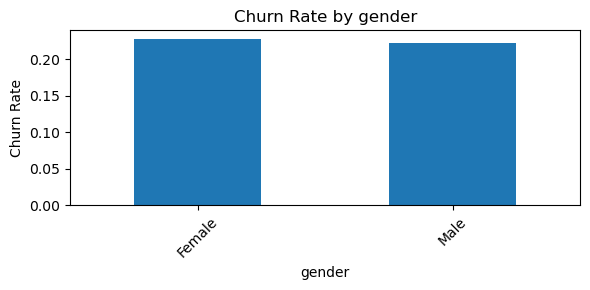

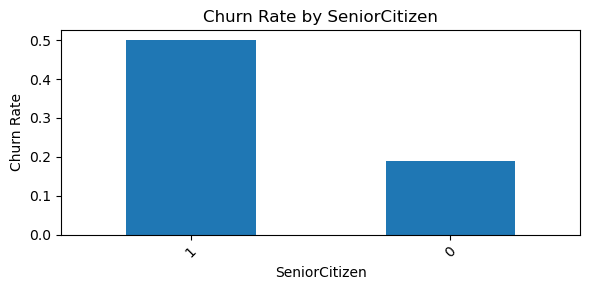

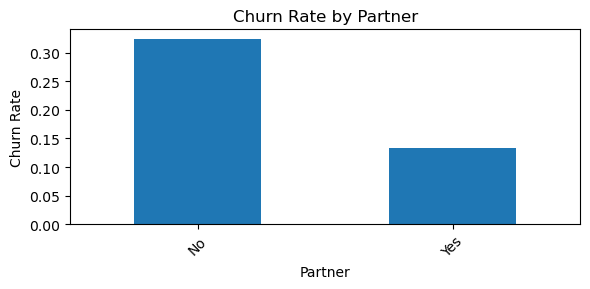

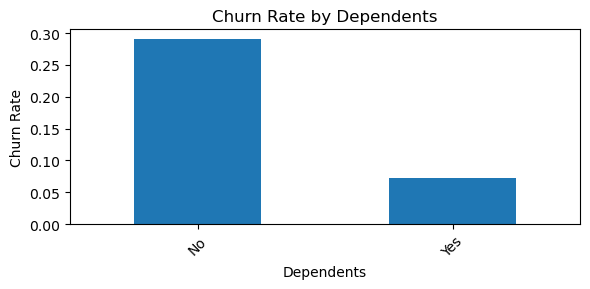

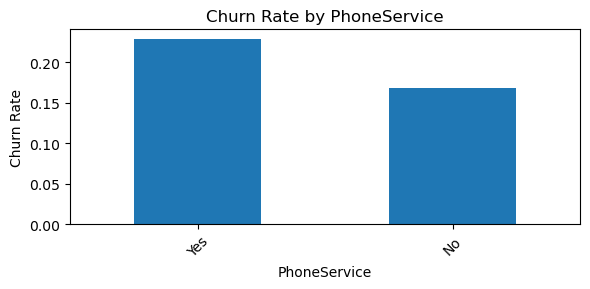

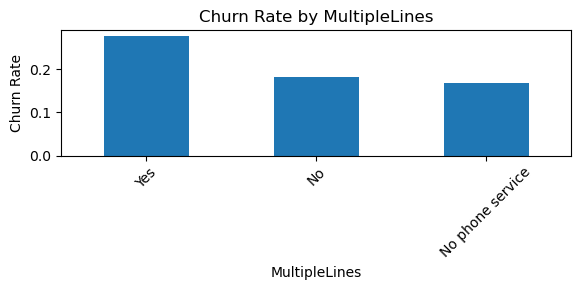

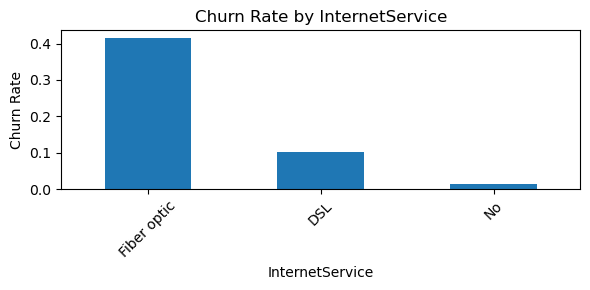

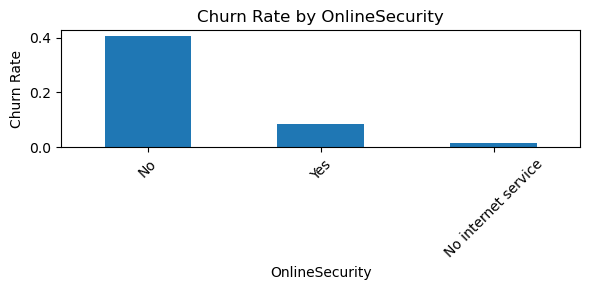

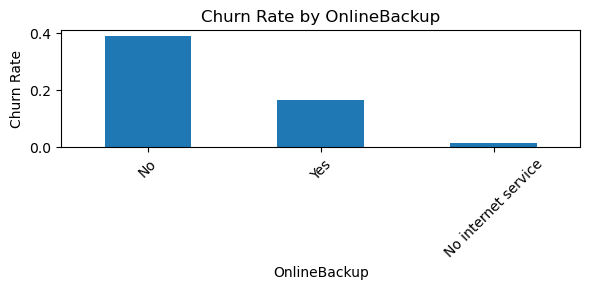

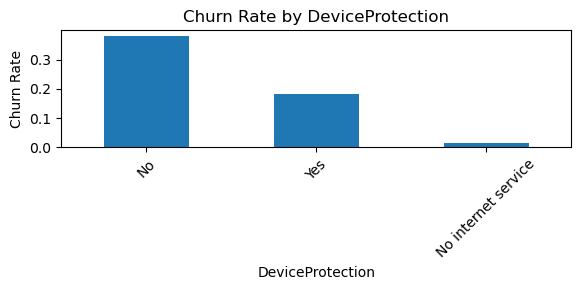

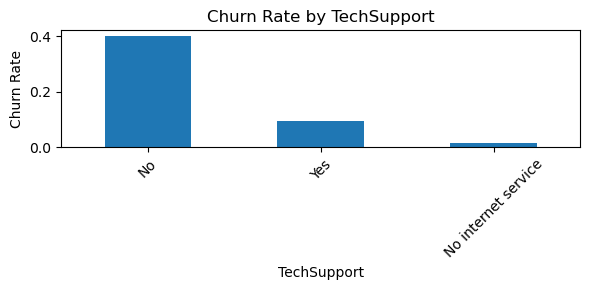

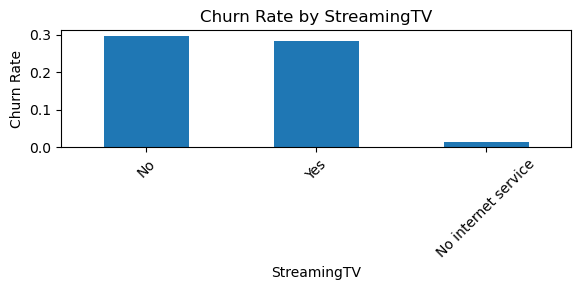

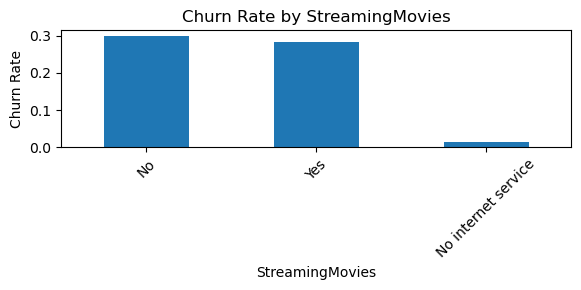

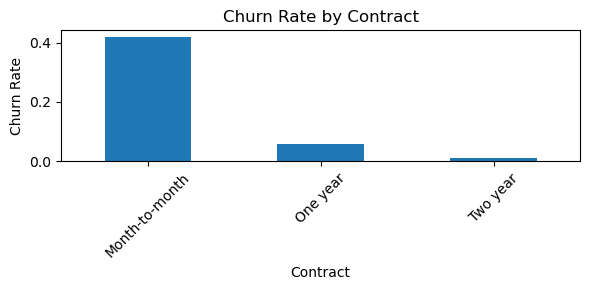

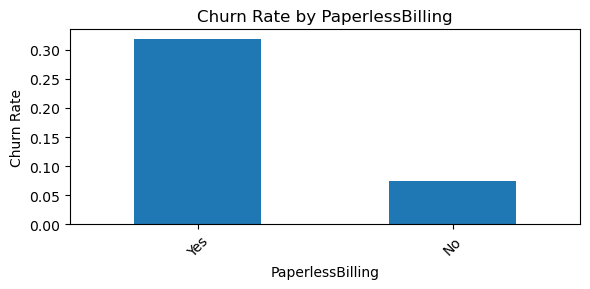

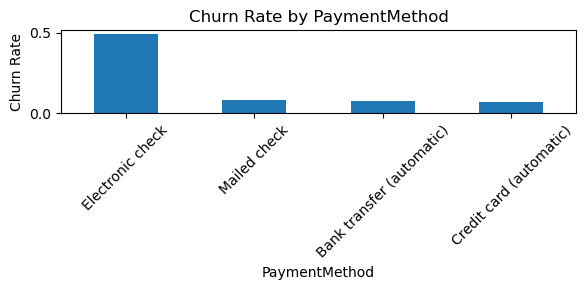

In [ ]:
df_temp = df_train.copy()
df_temp[target_col] = df_temp[target_col].map({'Yes': 1, 'No': 0})

for col in cat_cols:
    churn_rate = df_temp.groupby(col)[target_col].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(6, 3))
    churn_rate.plot(kind='bar')
    
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Analysis:

gender (low): as a standalone, variable, there is no significant variation in churn rate between Female and Male user. 

SeniorCitizen (high): Senior citizen customers are more likely to churn (0.5 vs 0.17)

Partner (high): Customers with no partner are more likely to churn (0.31 vs 0.12)

Dependents (high): Customers with no dependents are more likely to churn (0.27 vs 0.05)

PhoneService (medium): Customers who has phone service are more likely to churn (0.22 vs 0.16)

MultipleLines (medium): Customers with multiple line subscription are more likely to churn than those with no multiple line and those with no phone service (0.24 vs 0.17 vs 0.15)

InternetService (high): Customers with high fiber optic are more likely to churn than DSL and those with no internet (0.4 vs 0.1 vs 0.02)

OnlineSecurity (high): Customers with no OnlineSecurity are more likely to churn than those with OnlineSecurity and those with no internet (0.4 vs 0.13 vs 0.02) 

OnlineBackup (high): Customers with no OnlineBackup are more likely to churn than those with online back up and those with no internet service (0.4 vs 0.17 vs 0.02)

DeviceProtection (high): Customers with no DeviceProtection are more likely to churn than those with DeviceProtection and no internet service (0.3 vs 0.13 vs 0.02)

TechSupport (high): Similar to OnlineSecurity

StreamingTV (high): Those with no internet service are less likely to churn than those with No or Yes streamingTv (0.02 vs 0.3 vs 0.28)

StreamingMovies(high): Similar to StreamingTV

Contract (high): Those with Month-to-month contract are significantly more likely to churn than those with One year and Two year contracts (0.4 vs 0.05 vs 0.01)

PaperlessBilling (high): Those  with PaperlessBilling are significantly more likely to churn than those without PaperlessBilling (0.32 vs 0.06)

PaymentMethod (high): Those who pay with Electronic check are more likely to churn than those who paid with mailed check, bank transfer (automatic), and credit card (automatic) (0.5 vs 0.07 vs 0.06 vs 0.05)


In [ ]:
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target column:", target_col)

Numerical columns: ['MonthlyCharges', 'TotalCharges', 'tenure']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target column: Churn


#### 3.3.2. Variable Interaction Exploration

**Helper Functions**

In [ ]:
# Helper Functions for Categorical Association and Interaction Analysis
def cramers_v(x, y):
    """
    Cramer's V for association between two categorical variables.
    Returns a value between 0 and 1.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    # Bias correction
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(phi2corr / max((kcorr - 1), (rcorr - 1)))


def association_report(df, col1, col2):
    """
    Prints contingency table, row-normalized table,
    Cramer's V, and chi-square p-value.
    """
    ct = pd.crosstab(df[col1], df[col2])
    ct_row = pd.crosstab(df[col1], df[col2], normalize='index')
    chi2, p, dof, expected = chi2_contingency(ct)
    cv = cramers_v(df[col1], df[col2])

    print(f"\n{'='*70}")
    print(f"Association check: {col1} vs {col2}")
    print(f"{'='*70}")
    print("\nCounts:")
    print(ct)
    print("\nRow proportions:")
    print(ct_row.round(3))
    print(f"\nChi-square p-value: {p:.6f}")
    print(f"Cramer's V: {cv:.3f}")

    return ct, ct_row, p, cv


def interaction_churn_table(df, col1, col2, target_col="Churn"):
    """
    Returns count and churn-rate table for each (col1, col2) group.
    Assumes target_col contains Yes/No.
    """
    temp = df.copy()
    temp["_target_num"] = temp[target_col].map({"Yes": 1, "No": 0})

    summary = (
        temp.groupby([col1, col2], dropna=False)
            .agg(
                n=(target_col, "size"),
                churn_rate=("_target_num", "mean")
            )
            .reset_index()
            .sort_values("churn_rate", ascending=False)
    )

    return summary


def plot_interaction_heatmap(df, col1, col2, target_col="Churn", figsize=(8, 5)):
    """
    Heatmap of churn rate for variable interaction.
    """
    temp = df.copy()
    temp["_target_num"] = temp[target_col].map({"Yes": 1, "No": 0})

    heatmap_data = pd.pivot_table(
        temp,
        index=col1,
        columns=col2,
        values="_target_num",
        aggfunc="mean"
    )

    plt.figure(figsize=figsize)
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd")
    plt.title(f"Churn Rate Heatmap: {col1} vs {col2}")
    plt.ylabel(col1)
    plt.xlabel(col2)
    plt.tight_layout()
    plt.show()


def plot_interaction_bar(df, col1, col2, target_col="Churn", figsize=(8, 4)):
    """
    Grouped bar chart of churn rate for variable interaction.
    """
    temp = df.copy()
    temp["_target_num"] = temp[target_col].map({"Yes": 1, "No": 0})

    grouped = (
        temp.groupby([col1, col2])["_target_num"]
            .mean()
            .reset_index(name="churn_rate")
    )

    plt.figure(figsize=figsize)
    sns.barplot(data=grouped, x=col1, y="churn_rate", hue=col2)
    plt.title(f"Churn Rate by {col1} and {col2}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Interactions to Check**

In [ ]:
pairs_to_check = [
    ("gender", "SeniorCitizen"),
    ("Partner", "Dependents"),
    ("PhoneService", "MultipleLines"),
    ("OnlineSecurity", "OnlineBackup"),
    ("OnlineSecurity", "DeviceProtection"),
    ("OnlineSecurity", "TechSupport"),
    ("OnlineBackup", "DeviceProtection"),
    ("OnlineBackup", "TechSupport"),
    ("DeviceProtection", "TechSupport"),
    ("StreamingTV", "StreamingMovies"),
    ("PaperlessBilling", "PaymentMethod"),
]

In [ ]:
association_results = []

for col1, col2 in pairs_to_check:
    _, _, p, cv = association_report(df_train, col1, col2)
    association_results.append({
        "var1": col1,
        "var2": col2,
        "p_value": p,
        "cramers_v": cv
    })

association_df = pd.DataFrame(association_results).sort_values(
    by="cramers_v", ascending=False
)

association_df


Association check: gender vs SeniorCitizen

Counts:
SeniorCitizen       0      1
gender                      
Female         264661  34077
Male           261734  33722

Row proportions:
SeniorCitizen      0      1
gender                     
Female         0.886  0.114
Male           0.886  0.114

Chi-square p-value: 0.939878
Cramer's V: 0.000

Association check: Partner vs Dependents

Counts:
Dependents      No     Yes
Partner                   
No          271154   13486
Yes         143208  166346

Row proportions:
Dependents     No    Yes
Partner                 
No          0.953  0.047
Yes         0.463  0.537

Chi-square p-value: 0.000000
Cramer's V: 0.533

Association check: PhoneService vs MultipleLines

Counts:
MultipleLines      No  No phone service     Yes
PhoneService                                   
No                  0             36301       0
Yes            283384                 0  274509

Row proportions:
MultipleLines     No  No phone service    Yes
PhoneService 

,var1,var2,p_value,cramers_v
9,StreamingTV,StreamingMovies,0.000000,0.811297
5,OnlineSecurity,TechSupport,0.000000,0.754060
8,DeviceProtection,TechSupport,0.000000,0.740426
7,OnlineBackup,TechSupport,0.000000,0.734257
6,OnlineBackup,DeviceProtection,0.000000,0.732049
3,OnlineSecurity,OnlineBackup,0.000000,0.729444
4,OnlineSecurity,DeviceProtection,0.000000,0.728074
2,PhoneService,MultipleLines,0.000000,0.707107
1,Partner,Dependents,0.000000,0.532819
10,PaperlessBilling,PaymentMethod,0.000000,0.229441


**gender vs SeniorCitizen**

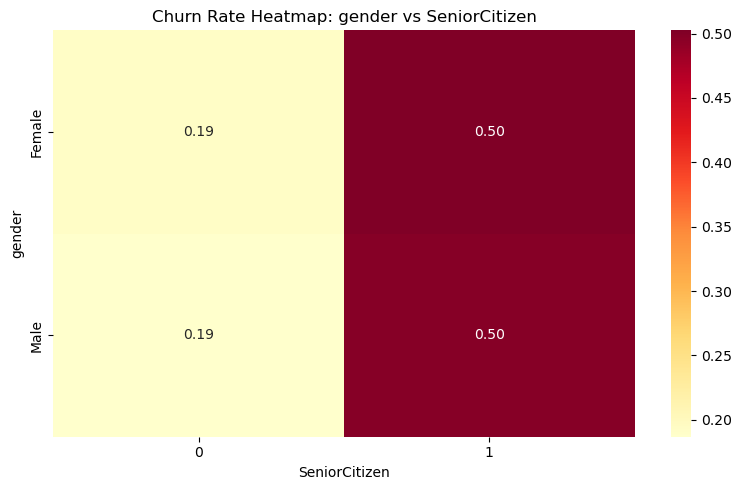

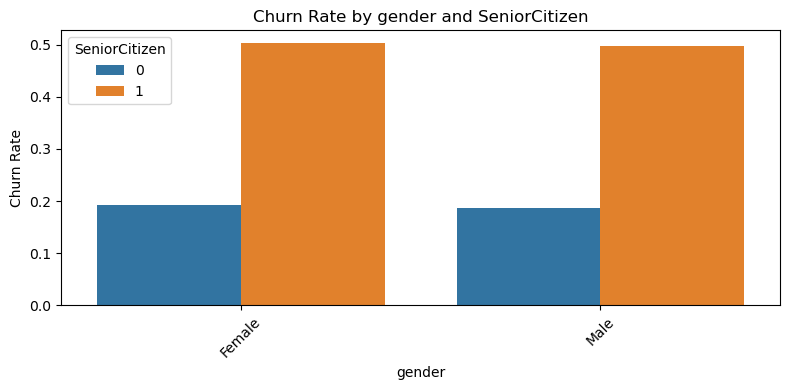

In [ ]:
summary_gender_senior = interaction_churn_table(df_train, "gender", "SeniorCitizen", target_col)
summary_gender_senior
plot_interaction_heatmap(df_train, "gender", "SeniorCitizen", target_col)
plot_interaction_bar(df_train, "gender", "SeniorCitizen", target_col)

Analysis: No variation in churn rate. 

**Partner vs Dependents**

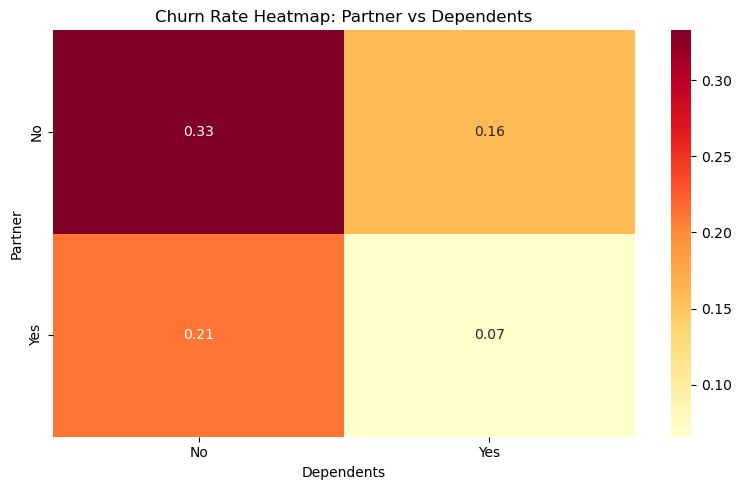

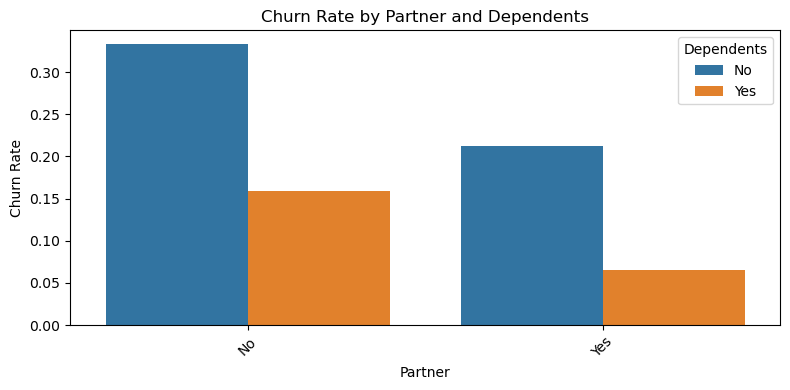

In [ ]:
summary_partner_dep = interaction_churn_table(df_train, "Partner", "Dependents", target_col)
summary_partner_dep
plot_interaction_heatmap(df_train, "Partner", "Dependents", target_col)
plot_interaction_bar(df_train, "Partner", "Dependents", target_col)

Analysis: Churn rates for those with no Dependents are high for either those with Partner (0.21) or no Partner (0.33). However, since those with no Dependents and no Partner have significantly higher churn rate, this suggests that single subscribers are much more likely to churn since they do not need to share the subscription with others. For those with dependents, the churn rate for those with no partner is significantly higher at 0.16 than those with Partner and Dependents at 0.07.  

**PhoneService vs MutlpleLines**

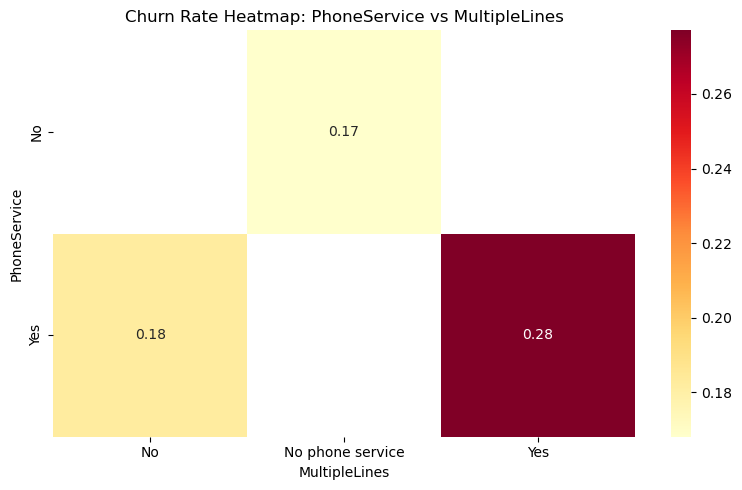

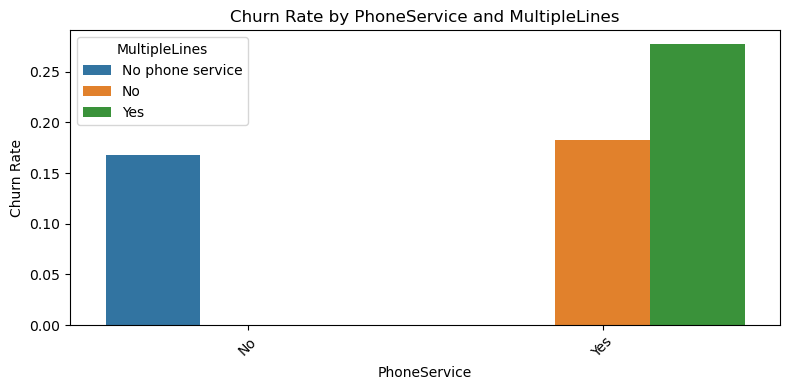

In [ ]:
summary_phone_multi = interaction_churn_table(df_train, "PhoneService", "MultipleLines", target_col)
summary_phone_multi
plot_interaction_heatmap(df_train, "PhoneService", "MultipleLines", target_col)
plot_interaction_bar(df_train, "PhoneService", "MultipleLines", target_col)

Analysis: The information contained within PhoneService is already covered in MutlipleLines who provides a richer information for those with PhoneService and Multiple PhoneService already. 

The churn rate for those with no phone service and one phone service are similar. Only those with MultipleLines have significantly have higher churn rate which indicate that one may choose to churn out of cost concern. 

**Security Subscriptions**


### OnlineSecurity x OnlineBackup


,OnlineSecurity,OnlineBackup,n,churn_rate
0,No,No,187094,0.472196
1,No,Yes,102380,0.285407
3,Yes,No,62989,0.149931
4,Yes,Yes,101004,0.047463
2,No internet service,No internet service,140727,0.014311


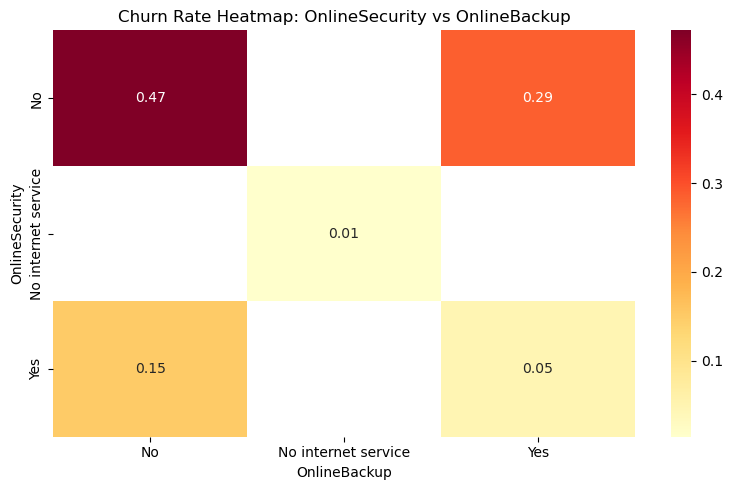


### OnlineSecurity x DeviceProtection


,OnlineSecurity,DeviceProtection,n,churn_rate
0,No,No,184530,0.460998
1,No,Yes,104944,0.309660
3,Yes,No,62847,0.144653
4,Yes,Yes,101146,0.050887
2,No internet service,No internet service,140727,0.014311


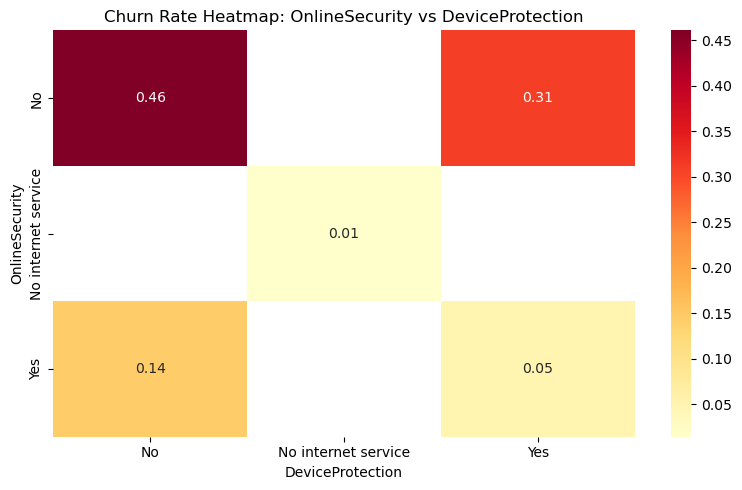


### OnlineSecurity x TechSupport


,OnlineSecurity,TechSupport,n,churn_rate
0,No,No,223036,0.469848
1,No,Yes,66438,0.192239
3,Yes,No,65535,0.169421
4,Yes,Yes,98458,0.031841
2,No internet service,No internet service,140727,0.014311


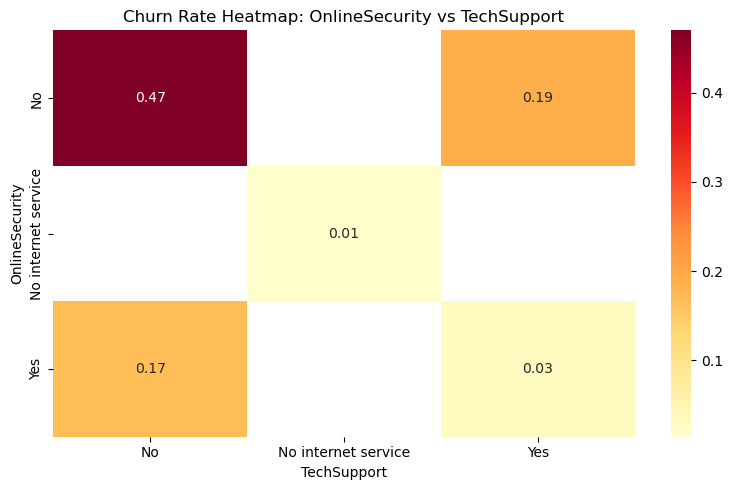


### OnlineBackup x DeviceProtection


,OnlineBackup,DeviceProtection,n,churn_rate
0,No,No,166515,0.442309
1,No,Yes,83568,0.288843
3,Yes,No,80862,0.253617
4,Yes,Yes,122522,0.110233
2,No internet service,No internet service,140727,0.014311


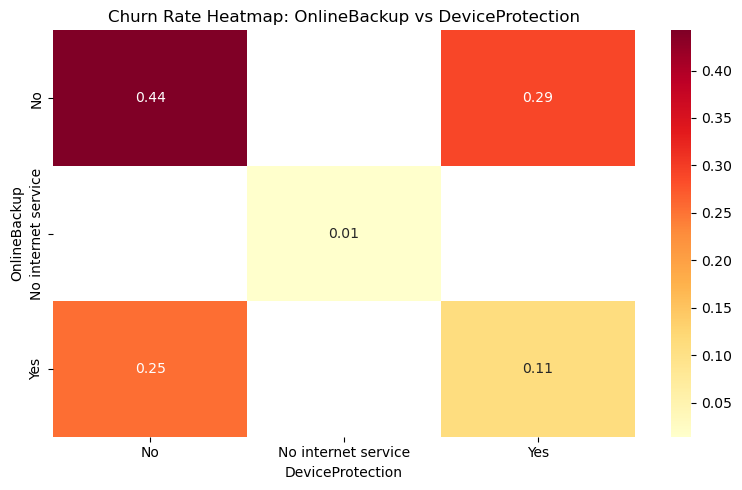


### OnlineBackup x TechSupport


,OnlineBackup,TechSupport,n,churn_rate
0,No,No,189496,0.463007
3,Yes,No,99075,0.284209
1,No,Yes,60587,0.165894
4,Yes,Yes,104309,0.056141
2,No internet service,No internet service,140727,0.014311


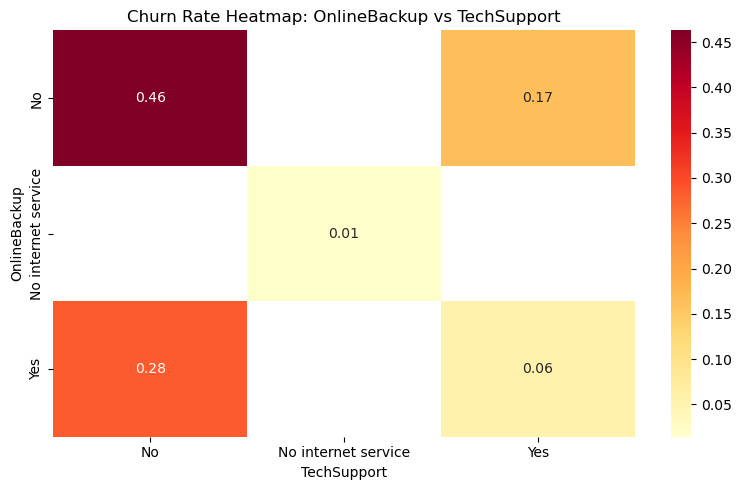


### DeviceProtection x TechSupport


,DeviceProtection,TechSupport,n,churn_rate
0,No,No,191157,0.445576
3,Yes,No,97414,0.315365
1,No,Yes,56220,0.159801
4,Yes,Yes,108676,0.063703
2,No internet service,No internet service,140727,0.014311


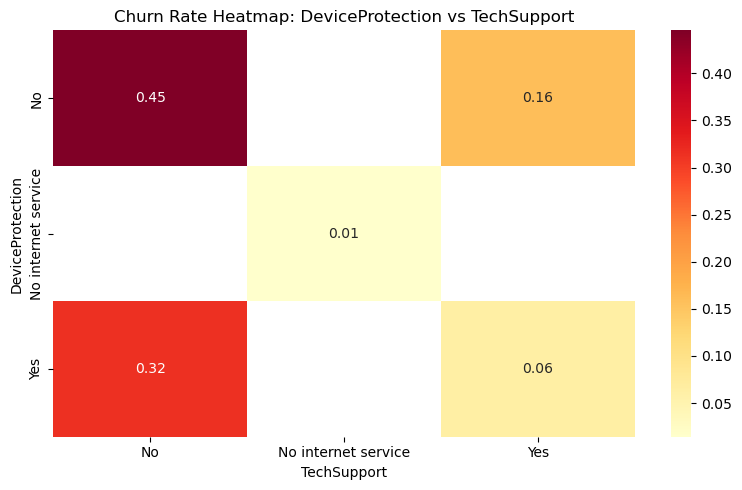

In [ ]:
security_pairs = [
    ("OnlineSecurity", "OnlineBackup"),
    ("OnlineSecurity", "DeviceProtection"),
    ("OnlineSecurity", "TechSupport"),
    ("OnlineBackup", "DeviceProtection"),
    ("OnlineBackup", "TechSupport"),
    ("DeviceProtection", "TechSupport"),
]

for col1, col2 in security_pairs:
    print(f"\n### {col1} x {col2}")
    display(interaction_churn_table(df_train, col1, col2, target_col))
    plot_interaction_heatmap(df_train, col1, col2, target_col)

Analysis: Consistently, if there none of security subscription variable is present, the churn rate is very high at close to 0.5, but when there is at least one or more present, the churn rate is significantly reduced. This suggests that the more services are attached to a customer, the more loyal they become. 

**SeniorCitizen vs PaperlessBilling**

,SeniorCitizen,PaperlessBilling,n,churn_rate
3,1,Yes,60010,0.527945
2,1,No,7789,0.287457
1,0,Yes,305569,0.278428
0,0,No,220826,0.067098


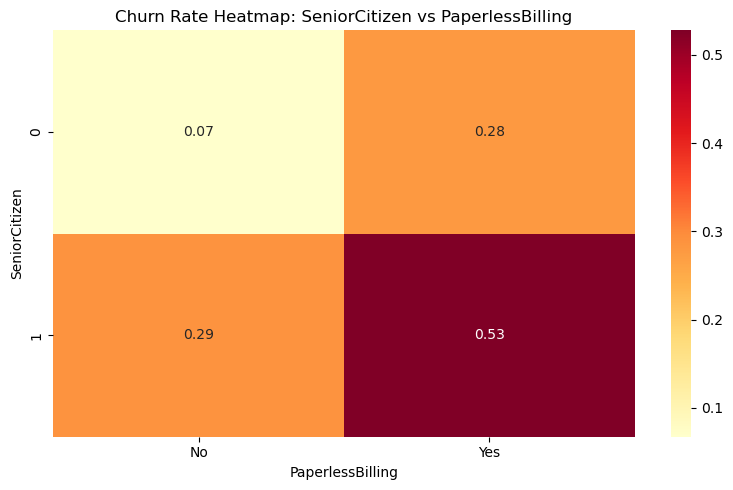

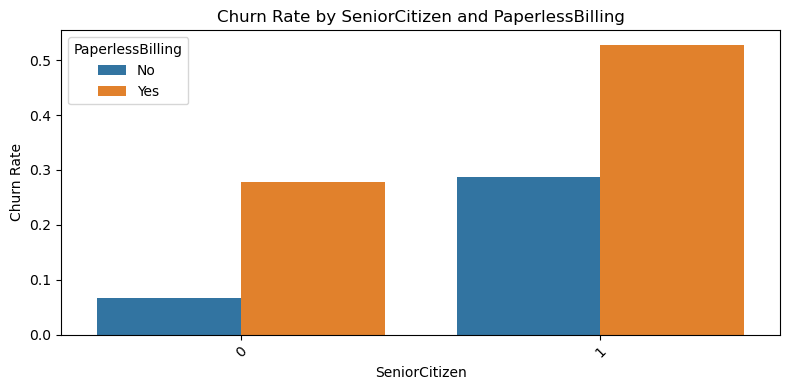

In [ ]:
summary = interaction_churn_table(df_train, "SeniorCitizen", "PaperlessBilling", target_col)
display(summary)
plot_interaction_heatmap(df_train, "SeniorCitizen", "PaperlessBilling", target_col)
plot_interaction_bar(df_train, "SeniorCitizen", "PaperlessBilling", target_col)

Analysis: PaperlessBilling significantly raises the churn rate for upto at least 0.28 for either SeniorCitizen or non-SeniorCitizen compared to non-SeniorCitizen and no PaperlessBilling whose churn rate is at 0.07. For both SeniorCitizen and PaperlessBilling, the churn rate is raised up to 0.53. Explanation could be that customers with PaperlessBilling are more tech savvy, and thus more knowledgeable of alternative services, leading to higher churn rate. 

In [ ]:
temp = df_train.copy()
temp["_target_num"] = temp[target_col].map({"Yes": 1, "No": 0})

summary = (
    temp.groupby(["SeniorCitizen", "PaperlessBilling", "PaymentMethod"])
        .agg(n=("Churn", "size"), churn_rate=("_target_num", "mean"))
        .reset_index()
        .sort_values("churn_rate", ascending=False)
)

summary.head(10)

,SeniorCitizen,PaperlessBilling,PaymentMethod,n,churn_rate
14,1,Yes,Electronic check,43478,0.638392
6,0,Yes,Electronic check,138510,0.483366
10,1,No,Electronic check,3691,0.477377
15,1,Yes,Mailed check,1410,0.436879
2,0,No,Electronic check,29693,0.298353
11,1,No,Mailed check,673,0.255572
12,1,Yes,Bank transfer (automatic),7501,0.228503
13,1,Yes,Credit card (automatic),7621,0.209421
7,0,Yes,Mailed check,39458,0.151072
4,0,Yes,Bank transfer (automatic),60721,0.101135


,PaymentMethod,PaperlessBilling,n,churn_rate
5,Electronic check,Yes,181988,0.520402
4,Electronic check,No,33384,0.318146
7,Mailed check,Yes,40868,0.160933
1,Bank transfer (automatic),Yes,68222,0.115139
3,Credit card (automatic),Yes,74501,0.102307
6,Mailed check,No,82889,0.039643
0,Bank transfer (automatic),No,53138,0.028247
2,Credit card (automatic),No,59204,0.027836


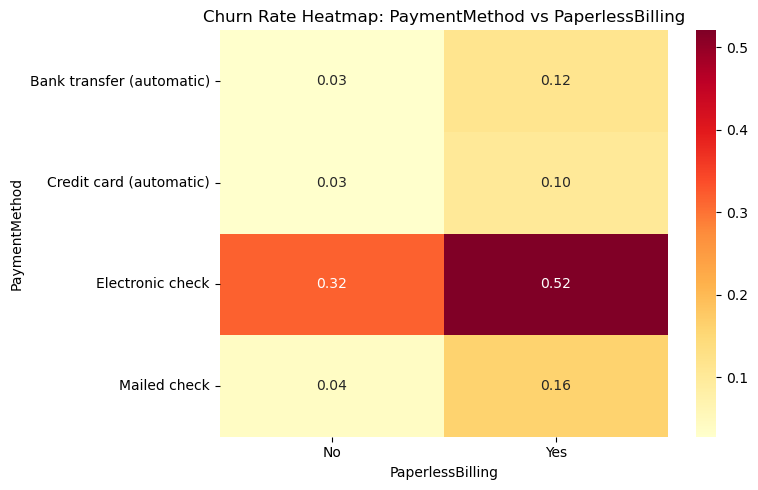

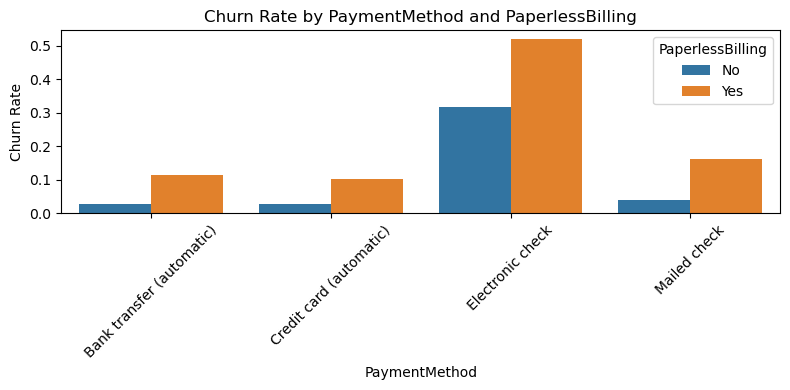

In [ ]:
summary = interaction_churn_table(df_train, "PaymentMethod", "PaperlessBilling", target_col)
display(summary)
plot_interaction_heatmap(df_train, "PaymentMethod", "PaperlessBilling", target_col)
plot_interaction_bar(df_train, "PaymentMethod", "PaperlessBilling", target_col)

In [ ]:
temp = df_train.copy()
temp["_target_num"] = temp[target_col].map({"Yes": 1, "No": 0})

summary = (
    temp.groupby(["OnlineSecurity", "OnlineBackup", "TechSupport",  "DeviceProtection"])
        .agg(n=("Churn", "size"), churn_rate=("_target_num", "mean"))
        .reset_index()
        .sort_values("churn_rate", ascending=False)
)

summary.head(10)

,OnlineSecurity,OnlineBackup,TechSupport,DeviceProtection,n,churn_rate
0,No,No,No,No,117205,0.526530
1,No,No,No,Yes,38411,0.473328
4,No,Yes,No,No,38085,0.414835
2,No,No,Yes,No,16690,0.321510
5,No,Yes,No,Yes,29335,0.310244
9,Yes,No,No,No,20956,0.269088
3,No,No,Yes,Yes,14788,0.208683
6,No,Yes,Yes,No,12550,0.174582
10,Yes,No,No,Yes,12924,0.170690
13,Yes,Yes,No,No,14911,0.135806
